In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel(r'C:\indian_railway_accident\Indian_Railways_Accidents_Dataset_1902_2024.xlsx',sheet_name='accidents_1902-2024')

In [3]:
df_fund = pd.read_excel(r'C:\indian_railway_accident\Indian_Railways_Accidents_Dataset_1902_2024.xlsx',sheet_name='funds_allocated')

In [4]:
df_rescue = pd.read_excel(r'C:\indian_railway_accident\Indian_Railways_Accidents_Dataset_1902_2024.xlsx',sheet_name='rescue_time')

In [5]:
for col in df.columns:
    if df[col].nunique() < 15:
        print(df[col].value_counts())
        print('.'*30)

Month
July         33
November     31
June         28
May          26
August       26
October      25
December     22
September    21
April        21
January      21
March        18
February     18
Name: count, dtype: int64
..............................
Standard Accident Type
Derailment            124
Collision             121
Fire                   20
Bombing                14
Structure Collapse      5
Attack                  4
Fatality                1
Level crossing          1
Name: count, dtype: int64
..............................
Rescue Time (hrs)
7    74
5    55
4    44
3    42
8    29
1    21
6    13
2    12
Name: count, dtype: int64
..............................
Standard Cause Type
Weather Conditions    124
Technical Fault       121
Human Error            26
Sabotage               18
Unknown                 1
Name: count, dtype: int64
..............................


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year                    290 non-null    int64  
 1   Month                   290 non-null    str    
 2   Day                     290 non-null    int64  
 3   Accident Name           290 non-null    str    
 4   Train Name              275 non-null    str    
 5   Location                290 non-null    str    
 6   State                   290 non-null    str    
 7   Accident Rail Zone      290 non-null    str    
 8   Accident Type           290 non-null    str    
 9   Standard Accident Type  290 non-null    str    
 10  Cause                   233 non-null    object 
 11  Deaths                  189 non-null    float64
 12  Injuries                138 non-null    float64
 13  Rescue Time (hrs)       290 non-null    int64  
 14  Reforms/Changes         41 non-null     str    
 15  

In [7]:
def get_year_casualties(year):
    casualties = df[df['Year'] == year]
    return casualties.groupby('Year')[['Deaths','Injuries']].sum().assign(total_casualties = lambda x: x['Deaths'] + x['Injuries']).sort_values('total_casualties',ascending=False).reset_index()

In [8]:
get_year_casualties(2023)

,Year,Deaths,Injuries,total_casualties
0,2023,355.0,1481.0,1836.0


In [9]:
def total_accidents(state):
    states = df[df['State'] == state]
    return states.groupby('Year')['Accident Name'].count()


In [10]:
total_accidents('Delhi')

Year
1951    1
1997    1
Name: Accident Name, dtype: int64

# Year
conclusion

In [11]:
df.groupby('Year',as_index=False).apply(lambda x: x.nlargest(1,'Deaths',keep='all')).reset_index(drop=True).sort_values('Deaths',ascending=False)

,Month,Day,Accident Name,Train Name,Location,State,Accident Rail Zone,Accident Type,Standard Accident Type,Cause,Deaths,Injuries,Rescue Time (hrs),Reforms/Changes,Standard Cause Type
50,June,6,Bihar Train Derailment,Unknown,Bagmati River Bridge,Bihar,East Central,Derailment,Derailment,Unknown,800.0,NaN,7,NaN,Weather Conditions
63,August,20,Firozabad Rail Disaster,"Purushottam Express, Kalindi Express",Near Firozabad,Uttar Pradesh,North Central,Collision,Collision,Stationary train,400.0,NaN,7,NaN,Technical Fault
67,August,2,Gaisal Train Disaster,"Brahmaputra Mail, Avadh Assam Express",Gaisal Station,Assam,North East Frontier,Collision,Collision,Stationary train,298.0,349.0,7,NaN,Technical Fault
91,June,2,Odisha Train Collision,"Coromandel Express, SMVT Bengaluru–Howrah SF E...","Balasore, Odisha",Odisha,East Coast,Collision,Collision,High speed collision with freight train,296.0,1289.0,7,NaN,Technical Fault
74,July,11,Mumbai Train Bombings,Multiple commuter trains,Mumbai,Maharashtra,Central,Bombings,Bombing,Terrorist bombing,230.0,790.0,5,NaN,Sabotage
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42,July,14,Mixed Train Derailment,234 Down Mixed Train,Between Golaghat and Furkating,Assam,North East Frontier,Derailment,Derailment,-,NaN,NaN,3,NaN,Weather Conditions
43,August,30,Kamrup Express Derailment,59 Up Kamrup Express,Between Samsi and Bhaluka Road Stations,West Bengal,North East Frontier,Derailment,Derailment,-,NaN,NaN,8,NaN,Weather Conditions
44,October,11,Patna Hatia Express Derailment,23 Up Patna Hatia Express,Between Silli and Kita Stations,Jharkhand,South Eastern,Derailment,Derailment,-,NaN,NaN,3,NaN,Weather Conditions
45,October,23,Suburban Train Derailment,No. 371 Down Suburban Train,Bandra Station,Maharashtra,Western,Derailment,Derailment,-,NaN,NaN,1,NaN,Weather Conditions


In [12]:
df.sort_values(['Deaths','Year'],ascending=[False,False]).groupby('Year',as_index=False).head(15)

,Year,Month,Day,Accident Name,Train Name,Location,State,Accident Rail Zone,Accident Type,Standard Accident Type,Cause,Deaths,Injuries,Rescue Time (hrs),Reforms/Changes,Standard Cause Type
97,1981,June,6,Bihar Train Derailment,Unknown,Bagmati River Bridge,Bihar,East Central,Derailment,Derailment,Unknown,800.0,NaN,7,NaN,Weather Conditions
131,1995,August,20,Firozabad Rail Disaster,"Purushottam Express, Kalindi Express",Near Firozabad,Uttar Pradesh,North Central,Collision,Collision,Stationary train,400.0,NaN,7,NaN,Technical Fault
149,1999,August,2,Gaisal Train Disaster,"Brahmaputra Mail, Avadh Assam Express",Gaisal Station,Assam,North East Frontier,Collision,Collision,Stationary train,298.0,349.0,7,NaN,Technical Fault
268,2023,June,2,Odisha Train Collision,"Coromandel Express, SMVT Bengaluru–Howrah SF E...","Balasore, Odisha",Odisha,East Coast,Collision,Collision,High speed collision with freight train,296.0,1289.0,7,NaN,Technical Fault
168,2006,July,11,Mumbai Train Bombings,Multiple commuter trains,Mumbai,Maharashtra,Central,Bombings,Bombing,Terrorist bombing,230.0,790.0,5,NaN,Sabotage
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45,1970,October,31,Madras-Mangalore Mail Collision,1 Down Madras-Mangalore Mail and 19 Down Madra...,Perambur Station,Tamil Nadu,Southern,Collision,Collision,-,NaN,NaN,8,NaN,Technical Fault
46,1970,November,5,Diesel Erb Special Collision,Down Diesel Erb Special 1 and 46 Down (Hyderab...,Between Retang and Bhubaneswar Stations,Odisha,East Coast,Collision,Collision,-,NaN,NaN,1,NaN,Technical Fault
25,1959,October,20,Bidanpur Station Head-on Collision,Agra Cantt-Allahabad Passenger & Ratlam Goods ...,Bidanpur Station,Uttar Pradesh,Northern,Collision,Collision,Human error,NaN,NaN,8,Stricter protocols for head-on collisions,Technical Fault
19,1957,July,23,Tatanagar Train Collision,Gua-Tata & 304 Down Hazaribagh-Ranchi-Howrah E...,Tatanagar,Jharkhand,South Eastern,Collision,Collision,Signal miscommunication,NaN,NaN,3,Improved signal systems,Technical Fault


In [13]:
def get_death(year):
    death = df[df['Year'] == year]
    return death.groupby('Year')['Deaths'].sum()

In [14]:
get_death(2022)

Year
2022    13.0
Name: Deaths, dtype: float64

In [15]:
def record_death(year):
    rec_death = df[df['Year'] == year]
    return rec_death.sort_values(['Deaths','Year'],ascending=[False,False]).groupby('Year',as_index=False).head(1)

In [16]:
record_death(2023)

,Year,Month,Day,Accident Name,Train Name,Location,State,Accident Rail Zone,Accident Type,Standard Accident Type,Cause,Deaths,Injuries,Rescue Time (hrs),Reforms/Changes,Standard Cause Type
268,2023,June,2,Odisha Train Collision,"Coromandel Express, SMVT Bengaluru–Howrah SF E...","Balasore, Odisha",Odisha,East Coast,Collision,Collision,High speed collision with freight train,296.0,1289.0,7,NaN,Technical Fault


# Month
conclusion
- Train accidents reach their highest frequency in July (33 incidents) 11.4% and November (31 incidents) 10.7%
- The early months of the year experience the lowest recorded accidents with February (18 incidents) and March (18 incidents) 6.2%
- Deadlist Months -> June and July recorded the highest total casualties, with over 3700 deaths and injuries each
- Safest Months -> January, February and March recorded the lowest number of casualties 

In [17]:
df.Month.value_counts()

Month
July         33
November     31
June         28
May          26
August       26
October      25
December     22
September    21
April        21
January      21
March        18
February     18
Name: count, dtype: int64

<Axes: >

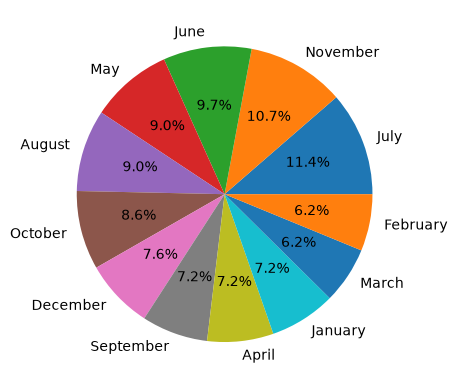

In [18]:
df.Month.value_counts().plot(kind='pie',autopct='%1.1f%%')

In [19]:
df.groupby('Month')['Deaths'].sum().sort_values(ascending=False)

Month
June         1623.0
July         1317.0
September    1045.0
August       1041.0
November      601.0
April         594.0
May           590.0
December      423.0
October       412.0
March         309.0
February      273.0
January       239.0
Name: Deaths, dtype: float64

In [20]:
df.groupby('Month')['Injuries'].sum().sort_values(ascending=False)

Month
July         2421.0
June         2408.0
August       1246.0
November      925.0
May           844.0
October       651.0
December      650.0
September     561.0
February      515.0
March         466.0
April         435.0
January       290.0
Name: Injuries, dtype: float64

In [21]:
df.groupby('Month')[['Deaths','Injuries']].sum().assign(total_casualties = lambda x : x['Deaths'] + x['Injuries']).sort_values('total_casualties',ascending=False).reset_index()

,Month,Deaths,Injuries,total_casualties
0,June,1623.0,2408.0,4031.0
1,July,1317.0,2421.0,3738.0
2,August,1041.0,1246.0,2287.0
3,September,1045.0,561.0,1606.0
4,November,601.0,925.0,1526.0
5,May,590.0,844.0,1434.0
6,December,423.0,650.0,1073.0
7,October,412.0,651.0,1063.0
8,April,594.0,435.0,1029.0
9,February,273.0,515.0,788.0


# Train Name
conclusion
- The top train name listed is Unknown with 20 cases, followed by broad categories like Passenger Train (6)
and Coromandel Express (5)
- There are 15 null (NaN) values in Train Name column
- Purushottam Express, Kalindi Express records thr highest fatalities at 400 deaths
- Coromandel Express, SMVT Bengaluru–Howrah SF Express has the highest overall casualities with 1,289 injuries and 296 deaths
- Multiple commuter trains has the second highest injury count at 790 injuries and 230 deaths
- Express Trains are the most dangerous they caussed the highest harm with 4431 deaths and 6847 injuries because they run fast and carry many people
- Other trains are second freight or unnmaed trains caused 3104 deaths and 3424 injuries
- Passenger trains have the lowest casualities local trains recorded fewer harm cases 932 deaths, 1141 injuries likely due to lower speeds
- the dataset contains 2300 unique train names (excluding 'Unknown')

In [22]:
df[df['Train Name'].isnull()]

,Year,Month,Day,Accident Name,Train Name,Location,State,Accident Rail Zone,Accident Type,Standard Accident Type,Cause,Deaths,Injuries,Rescue Time (hrs),Reforms/Changes,Standard Cause Type
50,1971,November,11,Lucknow Store Incharge Death,NaN,Lucknow,Uttar Pradesh,Northern,Fatality,Fatality,-,NaN,NaN,8,NaN,Unknown
51,1972,April,26,Train Derailment,NaN,Mysore State,Karnataka,South Western,Derailment,Derailment,-,21.0,37.0,7,NaN,Weather Conditions
79,1977,November,23,Train Derailment,NaN,Near Rewari,Haryana,Northern,Derailment,Derailment,Sabotage,20.0,21.0,4,NaN,Weather Conditions
190,2010,August,17,Goryamau Railway Station Crash,NaN,"Goryamau railway station, Barabanki",Uttar Pradesh,Northern,Crash,Collision,NaN,4.0,NaN,4,NaN,Technical Fault
191,2011,January,1,Akaltakth–Trucks Collision,NaN,"Babura railway crossing, Jaunpur district",Uttar Pradesh,Northern,Collision,Collision,Truck at railway crossing,NaN,NaN,3,NaN,Technical Fault
203,2012,March,20,Train Collision with Taxi Minivan,NaN,Northern Uttar Pradesh,Uttar Pradesh,Northern,Collision,Collision,Taxi at railway crossing,15.0,NaN,4,NaN,Technical Fault
215,2013,November,13,Chapramari Forest Train Accident,NaN,"Chapramari Wildlife Sanctuary, West Bengal",West Bengal,Eastern,Collision,Collision,Herd of elephants,0.0,10.0,3,NaN,Technical Fault
251,2018,October,19,Amritsar Train Disaster,NaN,Amritsar,Punjab,Northern,Collision,Collision,Train ran into crowd at Dusshera festival,59.0,100.0,5,NaN,Technical Fault
257,2020,May,8,Aurangabad Railway Accident,NaN,Between Jalna and Aurangabad districts,Maharashtra,Central,Collision,Collision,Goods train ran over sleeping migrants,16.0,NaN,5,NaN,Technical Fault
258,2020,July,22,Hyderabad Railway Employees Accident,NaN,Between Vikarabad and Chittigadda railway station,Telangana,South Central,Collision,Collision,Double engine train ran over employees,3.0,NaN,4,NaN,Technical Fault


In [23]:
df['Train Name'].value_counts()

Train Name
Unknown                                           20
Passenger Train                                    6
Coromandel Express                                 5
Express Train                                      3
Passenger & Freight Train                          2
                                                  ..
Delhi-Darbhanga Superfast Express                  1
Ernakulam-Hazrat Nizamuddin Millennium Express     1
Kanchanjunga Express                               1
Dibrugarh–Chandigarh Express                       1
Howrah–Mumbai CSMT Mail                            1
Name: count, Length: 231, dtype: int64

In [24]:
train_rec = df[df['Train Name'] != 'Unknown'].groupby('Train Name')[['Deaths','Injuries']].sum().sort_values('Deaths',ascending=False)

In [25]:
bihar = df[df['State'] == 'Bihar']
bihar[bihar['Train Name'] == 'Unknown']

,Year,Month,Day,Accident Name,Train Name,Location,State,Accident Rail Zone,Accident Type,Standard Accident Type,Cause,Deaths,Injuries,Rescue Time (hrs),Reforms/Changes,Standard Cause Type
8,1950,May,7,Bihar Train Bridge Collapse,Unknown,Bihar,Bihar,East Central,Derailment,Derailment,Bridge collapse,81.0,100.0,5,New bridge safety protocols,Weather Conditions
97,1981,June,6,Bihar Train Derailment,Unknown,Bagmati River Bridge,Bihar,East Central,Derailment,Derailment,Unknown,800.0,NaN,7,NaN,Weather Conditions
109,1986,March,10,Khagaria Rail Disaster,Unknown,Khagaria,Bihar,East Central,Collision,Collision,Unknown,58.0,NaN,4,NaN,Technical Fault
124,1993,July,16,Darbhanga Train Accident,Unknown,Darbhanga District,Bihar,East Central,Derailment,Derailment,Unknown,60.0,NaN,5,NaN,Weather Conditions


In [26]:
train_type_summary = df.assign(train_type= np.where(df['Train Name'].str.contains('Express',case=False,na=False), 'Express',np.where(df['Train Name'].str.contains('Passenger',case=False,na=False), 'Passenger', 'Other')))\
.groupby('train_type')[['Deaths','Injuries']].sum().sort_values('Deaths',ascending=False)

In [27]:
train_type_summary

,Deaths,Injuries
train_type,,
Express,4431.0,6847.0
Other,3104.0,3424.0
Passenger,932.0,1141.0


In [28]:
def find_train(state_name):
    st_name = df[df['State'] == state_name]
    return st_name[st_name['Train Name'] != 'Unknown'].groupby(['Year','Month','State','Accident Rail Zone','Location'])['Train Name'].unique().reset_index()

In [29]:
find_train('Bihar')

,Year,Month,State,Accident Rail Zone,Location,Train Name
0,1937,July,Bihar,East Central,"Near Bihta Station, Patna",[Upper India Express]
1,1953,June,Bihar,East Central,Between Sempaore and Kalihar,[Passenger & Freight Train]
2,1961,January,Bihar,East Central,Near Umeshnagar,[Passenger Trains]
3,1961,March,Bihar,East Central,Between Kalihar and Bihar,[Passenger & Freight Train]
4,1962,July,Bihar,East Central,Dumraon Railway Station,[Punjab Mail]
5,1974,November,Bihar,East Central,Between Rampur Dumra and Hatidih Link Cabin,[311 Up Sealdah Samastipur Fast Passenger]
6,1990,April,Bihar,East Central,Near Patna,[Shuttle Train]
7,1990,June,Bihar,East Central,Mangra,"[Freight Train, Passenger Train]"
8,1998,April,Bihar,East Central,Near Fatuha Station,[Howrah–Danapur Express]
9,2002,September,Bihar,East Central,Gaya-Dehri-on-Sone Bridge,[Howrah Rajdhani Express]


In [30]:
df.State.value_counts()

State
Uttar Pradesh        60
Tamil Nadu           31
Maharashtra          28
Andhra Pradesh       24
Bihar                20
West Bengal          20
Telangana            13
Assam                13
Madhya Pradesh       11
Karnataka            10
Punjab                9
Gujarat               8
Odisha                8
Kerala                8
Jharkhand             7
Haryana               5
Rajasthan             4
Uttarakhand           2
Delhi                 2
Himachal Pradesh      2
Unknown               2
Arunachal Pradesh     1
Jammu and Kashmir     1
Mizoram               1
Name: count, dtype: int64

# Location
conclusion
- High Diversity -> Almost every location in the dataset is unique, meaaning train accidents are spread out randomly
across hundreds of different spot rather than repeating at just one specific location
- Data Imbalance -> Because over 250 location appear onlt once, plotting or modeling indiviual location names is not very useful for finding overall patters
- Deadliest Hotspots -> Bagmati River Bridge 800 deaths and Near firozabad 400 deaths 
- High Injury Location -> Places like Balasore, Odisha 1289 and mumbai 790 injuries recorded high numbers of injured people

In [31]:
df['Location'].value_counts()

Location
Unknown                                      4
Bihar                                        2
Kesamudram Station                           2
Between Bhavani Nagar and Takari Stations    2
Near Sarupeta Station                        2
                                            ..
Near Ramagundam, Telangana                   1
Near Rangapani, Darjeeling                   1
Near Jhilahi, Gonda district                 1
Near Jamshedpur, Jharkhand                   1
Near Kanpur, Uttar Pradesh                   1
Name: count, Length: 277, dtype: int64

In [32]:
df['Location'].describe()

count         290
unique        277
top       Unknown
freq            4
Name: Location, dtype: object

In [33]:
df.head(5)

,Year,Month,Day,Accident Name,Train Name,Location,State,Accident Rail Zone,Accident Type,Standard Accident Type,Cause,Deaths,Injuries,Rescue Time (hrs),Reforms/Changes,Standard Cause Type
0,1902,September,12,Bombay-Madras Mail Derailment,Bombay-Madras Mail,"Near Mangapatnam, Kadapa District",Andhra Pradesh,South Central,Derailment,Derailment,Structural failure on bridge,100.0,138.0,4,Enhanced bridge inspections,Weather Conditions
1,1907,October,24,Kot Lakhpat Train Collision,Passenger & Freight,Kot Lakhpat Station,Gujarat,North Western,Collision,Collision,Signal miscommunication,11.0,27.0,7,Improved signal communication systems,Technical Fault
2,1908,December,2,Barara Train Collision,Mail Trains,Barara Station,Haryana,Northern,Collision,Collision,Human error,22.0,24.0,7,Stricter rules for train dispatching,Technical Fault
3,1920,April,27,Doon Express Train Collision,Doon Express & Goods Train,Near Moradabad,Uttar Pradesh,Northern,Collision,Collision,Signal failure,120.0,50.0,7,Improved signal maintenance,Technical Fault
4,1920,October,7,Madras-Bangalore Mail Derailment,Madras-Bangalore Mail,3 km past Arakkonam,Tamil Nadu,Southern,Derailment,Derailment,Track fracture,40.0,64.0,7,Enhanced track monitoring,Weather Conditions


In [34]:
df.groupby('Location')[['Deaths','Injuries']].sum().sort_values('Deaths',ascending=False).head(10)

,Deaths,Injuries
Location,,
Bagmati River Bridge,800.0,0.0
Near Firozabad,400.0,0.0
Gaisal Station,298.0,349.0
"Balasore, Odisha",296.0,1289.0
Mumbai,230.0,790.0
Khanna,227.0,0.0
"Charegaon, Balaghat",157.0,0.0
"Pukhrayan, approx 60 km from Kanpur",152.0,260.0
Gaya-Dehri-on-Sone Bridge,140.0,0.0


In [35]:
strip_loc=df['Location'].str.split(',').str[-1].str.strip()

In [36]:
clean_loc = (
    strip_loc.str.replace('near','',case=False)
    .str.replace('district','',case=False)
    .str.strip()
)

In [37]:
specific_location = clean_loc[~clean_loc.isin(df['State'])]

In [38]:
df.groupby(specific_location)[['Deaths','Injuries']].sum().sort_values('Deaths',ascending=False).head(10)

,Deaths,Injuries
Location,,
Bagmati River Bridge,800.0,0.0
Firozabad,400.0,0.0
Gaisal Station,298.0,349.0
Mumbai,230.0,790.0
Khanna,227.0,0.0
Patna,189.0,180.0
Moradabad,161.0,113.0
Balaghat,157.0,0.0
approx 60 km from Kanpur,152.0,260.0


In [39]:
clean_loc.dropna()

0                   Kadapa
1      Kot Lakhpat Station
2           Barara Station
3                Moradabad
4      3 km past Arakkonam
              ...         
285              Telangana
286             Darjeeling
287                  Gonda
288              Jharkhand
289          Uttar Pradesh
Name: Location, Length: 290, dtype: object

# State
conclusion
- Uttar Pradesh is the worst affected state it tops the list with 3676 total casualties 
(1,664 fatalities and 2,012 injuries).
- Top 3 States account for the most fatalities and injuries Uttar Pradesh, Bihar (2,187 casualties 1620 fatalities) and
Andhra Pradesh (1,926 casualties 763 fatalities)
- Huge gap between top and bottom while Uttar Pradesh recorded over 3,600 caualties
states like Arunachal Pradesh recorded 0 fatalities or injuries and Jammu & Kashmir recorded on;y 20 casualties (0 fatalities)
- Targeted action needed Because casualties are concentrated in afew specific regions saftey budgets and track upgrades should focus on these high-impact states first

In [40]:
df.head(3)

,Year,Month,Day,Accident Name,Train Name,Location,State,Accident Rail Zone,Accident Type,Standard Accident Type,Cause,Deaths,Injuries,Rescue Time (hrs),Reforms/Changes,Standard Cause Type
0,1902,September,12,Bombay-Madras Mail Derailment,Bombay-Madras Mail,"Near Mangapatnam, Kadapa District",Andhra Pradesh,South Central,Derailment,Derailment,Structural failure on bridge,100.0,138.0,4,Enhanced bridge inspections,Weather Conditions
1,1907,October,24,Kot Lakhpat Train Collision,Passenger & Freight,Kot Lakhpat Station,Gujarat,North Western,Collision,Collision,Signal miscommunication,11.0,27.0,7,Improved signal communication systems,Technical Fault
2,1908,December,2,Barara Train Collision,Mail Trains,Barara Station,Haryana,Northern,Collision,Collision,Human error,22.0,24.0,7,Stricter rules for train dispatching,Technical Fault


In [41]:
(df.groupby('State')[['Deaths','Injuries']].sum().assign(Total_casualties = lambda x: x['Deaths'] + x['Injuries'])
 .sort_values('Total_casualties',ascending=False))

,Deaths,Injuries,Total_casualties
State,,,
Uttar Pradesh,1664.0,2012.0,3676.0
Bihar,1620.0,567.0,2187.0
Andhra Pradesh,763.0,1163.0,1926.0
Maharashtra,539.0,1273.0,1812.0
Odisha,348.0,1411.0,1759.0
Assam,541.0,845.0,1386.0
West Bengal,288.0,863.0,1151.0
Tamil Nadu,444.0,530.0,974.0
Punjab,452.0,355.0,807.0


In [42]:
total_fatality = df.groupby('State')[['Deaths','Injuries']].sum().assign(Total_casualties = lambda x: x['Deaths'] + x['Injuries'])\
 .sort_values('Total_casualties',ascending=False)

In [43]:
def cause_train(states):
    sta_name = df[df['State'] == states]
    return sta_name[sta_name['Train Name'] != 'Unknown'].groupby(['Year','Month','State','Accident Rail Zone','Location','Train Name']).agg(
        total_death = ('Deaths','sum'),
        total_injuries = ('Injuries','sum')
    ).reset_index()

In [44]:
cause_train('Odisha')

,Year,Month,State,Accident Rail Zone,Location,Train Name,total_death,total_injuries
0,1970,November,Odisha,East Coast,Between Retang and Bhubaneswar Stations,Down Diesel Erb Special 1 and 46 Down (Hyderab...,0.0,0.0
1,1984,August,Odisha,East Coast,"Chhattrapur, near Berhampur",Coromandel Express,16.0,0.0
2,1995,June,Odisha,East Coast,Barpali,Hirakud Express,15.0,0.0
3,1999,December,Odisha,East Coast,Jenapur,Coromandel Express,20.0,100.0
4,2009,February,Odisha,East Coast,Jajpur Road Station,Coromandel Express,0.0,0.0
5,2016,September,Odisha,East Coast,"Cuttack, Odisha",Bhubaneswar-Bhadrak Passenger,1.0,22.0
6,2017,November,Odisha,East Coast,Between Goraknath-Raghunathpur,Paradeep-Cuttack Goods Train,0.0,0.0
7,2023,June,Odisha,East Coast,"Balasore, Odisha","Coromandel Express, SMVT Bengaluru–Howrah SF E...",296.0,1289.0


In [45]:
cause_train('Odisha')

,Year,Month,State,Accident Rail Zone,Location,Train Name,total_death,total_injuries
0,1970,November,Odisha,East Coast,Between Retang and Bhubaneswar Stations,Down Diesel Erb Special 1 and 46 Down (Hyderab...,0.0,0.0
1,1984,August,Odisha,East Coast,"Chhattrapur, near Berhampur",Coromandel Express,16.0,0.0
2,1995,June,Odisha,East Coast,Barpali,Hirakud Express,15.0,0.0
3,1999,December,Odisha,East Coast,Jenapur,Coromandel Express,20.0,100.0
4,2009,February,Odisha,East Coast,Jajpur Road Station,Coromandel Express,0.0,0.0
5,2016,September,Odisha,East Coast,"Cuttack, Odisha",Bhubaneswar-Bhadrak Passenger,1.0,22.0
6,2017,November,Odisha,East Coast,Between Goraknath-Raghunathpur,Paradeep-Cuttack Goods Train,0.0,0.0
7,2023,June,Odisha,East Coast,"Balasore, Odisha","Coromandel Express, SMVT Bengaluru–Howrah SF E...",296.0,1289.0


# Accident Rail Zone
conclusion
- most Accidents Northern Railway had the most accidents (54), followed by Southern (41) and Eastern (36)
- Most casualities Bihar (East Cetral) suffered the highest casualities, with 1,620 deaths and 567 injuries
- Key Finding -> Most regions have low casualties, but a few high risk areas account for most severe accidents
- Action -> safety upgrades should focus on high risk zones like East Central, East Coast, and North Central to prevent the most harm  


In [46]:
df.sample(1)

,Year,Month,Day,Accident Name,Train Name,Location,State,Accident Rail Zone,Accident Type,Standard Accident Type,Cause,Deaths,Injuries,Rescue Time (hrs),Reforms/Changes,Standard Cause Type
165,2005,October,3,Datia Rail Accident,Bundelkhand Express,Near Datia,Madhya Pradesh,North Central,Derailment,Derailment,Overspeeding,16.0,100.0,5,NaN,Weather Conditions


In [47]:
df['Accident Rail Zone'].value_counts()

Accident Rail Zone
Northern               54
Southern               41
South Central          36
East Central           23
North Central          23
North East Frontier    21
Central                18
Eastern                14
Western                14
East Coast             13
South Western           7
North Eastern           6
South Eastern           6
West Central            6
North Western           4
South East Central      3
Konkan                  1
Name: count, dtype: int64

In [48]:
(df.groupby(['State','Accident Rail Zone'])[['Deaths','Injuries']].sum().
 assign(Accident_rail_zone = lambda x : x['Deaths'] + x['Injuries']).sort_values('Accident_rail_zone',ascending=False))

,,Deaths,Injuries,Accident_rail_zone
State,Accident Rail Zone,,,
Bihar,East Central,1620.0,567.0,2187.0
Odisha,East Coast,348.0,1411.0,1759.0
Uttar Pradesh,North Central,901.0,762.0,1663.0
Maharashtra,Central,421.0,1141.0,1562.0
Uttar Pradesh,Northern,512.0,979.0,1491.0
Assam,North East Frontier,541.0,845.0,1386.0
Andhra Pradesh,South Central,595.0,561.0,1156.0
Tamil Nadu,Southern,444.0,530.0,974.0
Punjab,Northern,452.0,355.0,807.0


In [49]:
acc_rail_zone = (df.groupby(['State','Accident Rail Zone'])[['Deaths','Injuries']].sum().
 assign(Accident_rail_zone = lambda x : x['Deaths'] + x['Injuries']).sort_values('Accident_rail_zone',ascending=False))

<Axes: ylabel='Frequency'>

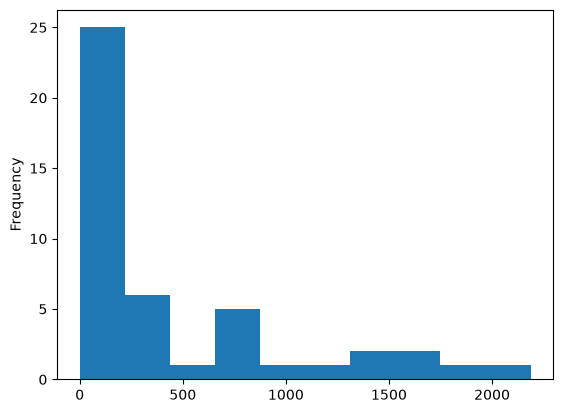

In [50]:
acc_rail_zone['Accident_rail_zone'].plot(kind='hist')

<Axes: ylabel='Density'>

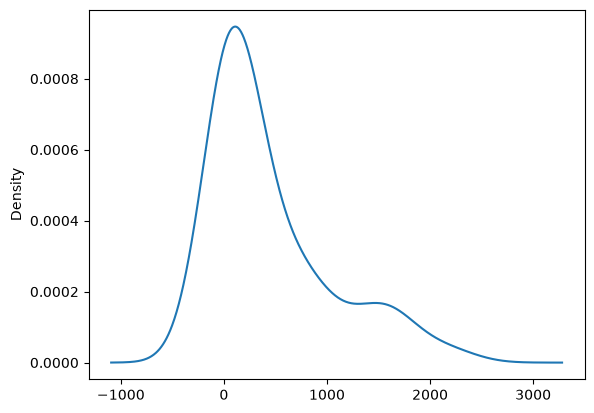

In [51]:
acc_rail_zone['Accident_rail_zone'].plot(kind='kde')

In [52]:
acc_rail_zone['Accident_rail_zone'].skew()

np.float64(1.4768399108827255)

# Accident Type and Standard Accident Type
conclusion 
- Data standardization -> I dropped Accident type and kept Standard Accident Type to fix inconsistencies - for example reclasifying raw entries like Explosion under the standard category bombing
- Most Frequent Types -> derailment(124 cases) and collision (121 cases) account for the majority of all train accidents
- Specific Causes -> Common specific causes include track issues, signal errors and strucral failures (like bridge collapse)
- Severity -> Collisions are the most fatal, driving the highest casualties 2387 deaths, 3,124 injuries despite fewer overall occurrences
- Actionable Focus -> safety upgrades must target track maintenance signaling and structural collapse prevention to mitigate high severity incidents

In [53]:
df.sample(1)

,Year,Month,Day,Accident Name,Train Name,Location,State,Accident Rail Zone,Accident Type,Standard Accident Type,Cause,Deaths,Injuries,Rescue Time (hrs),Reforms/Changes,Standard Cause Type
92,1979,November,22,Saurashtra Mail Derailment,6 Up Saurashtra Mail and 24 Down Somnath Mail,Sabarmati Station,Gujarat,Western,Derailment & Collision,Derailment,-,NaN,NaN,3,NaN,Weather Conditions


In [54]:
df['Standard Accident Type'].value_counts()

Standard Accident Type
Derailment            124
Collision             121
Fire                   20
Bombing                14
Structure Collapse      5
Attack                  4
Fatality                1
Level crossing          1
Name: count, dtype: int64

In [55]:
df.groupby('Standard Accident Type')['Cause'].value_counts().reset_index().sort_values('Standard Accident Type',ascending=False).head(15)

,Standard Accident Type,Cause,count
110,Structure Collapse,Improper chaining of upper berth,1
109,Structure Collapse,Tank collapse,1
108,Structure Collapse,35,1
107,Structure Collapse,Bridge collapse,1
106,Structure Collapse,-,1
105,Level crossing,59,1
100,Fire,-,1
97,Fire,Unknown,3
98,Fire,Fire in train,2
99,Fire,Fire in coaches,2


In [56]:
df.groupby('Standard Accident Type')['Cause'].value_counts().reset_index().sort_values('Standard Accident Type',ascending=False).tail(15)

,Standard Accident Type,Cause,count
36,Collision,Tractor trolley collision,1
42,Collision,Bus at unmanned crossing,1
8,Bombing,Bombing,1
5,Bombing,Bombing (Naga separatists),3
6,Bombing,Bomb explosion,2
7,Bombing,Bomb explosions,1
12,Bombing,Transporting explosives,1
9,Bombing,Crackers exploded in wagon,1
10,Bombing,Terrorist bombing,1
11,Bombing,Suspected terrorist bomb,1


In [57]:
std_acc_type = pd.crosstab(df['Deaths'],df['Standard Accident Type'],normalize='columns')*100
std_acc_type.sort_values('Deaths',ascending=False)

Standard Accident Type,Attack,Bombing,Collision,Derailment,Fire,Level crossing,Structure Collapse
Deaths,,,,,,,
800.0,0.000000,0.000000,0.000000,1.388889,0.000000,0.0,0.0
400.0,0.000000,0.000000,1.219512,0.000000,0.000000,0.0,0.0
298.0,0.000000,0.000000,1.219512,0.000000,0.000000,0.0,0.0
296.0,0.000000,0.000000,1.219512,0.000000,0.000000,0.0,0.0
230.0,0.000000,7.692308,0.000000,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...
4.0,0.000000,0.000000,4.878049,6.944444,0.000000,0.0,0.0
3.0,33.333333,0.000000,3.658537,1.388889,0.000000,0.0,20.0
2.0,0.000000,0.000000,4.878049,5.555556,0.000000,0.0,0.0


In [58]:
df.groupby(['Standard Accident Type']).agg(
    total_death=('Deaths','sum'),
    total_injuries=('Injuries','sum'),
    cause=('Cause','count')
).sort_values('total_death',ascending=False).reset_index().dropna()

,Standard Accident Type,total_death,total_injuries,cause
0,Derailment,3997.0,5104.0,77
1,Collision,3387.0,4499.0,115
2,Bombing,510.0,1350.0,14
3,Fire,395.0,73.0,16
4,Structure Collapse,92.0,135.0,5
5,Attack,61.0,251.0,4
6,Level crossing,25.0,0.0,1
7,Fatality,0.0,0.0,1


# Creating DateTime column using Year Month Day columns

In [59]:
df['DateTime'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-' + df['Day'].astype(str), format='%Y-%B-%d')

In [60]:
df.insert(0,'DateTime', df.pop('DateTime'))

In [61]:
df.head(1)

,DateTime,Year,Month,Day,Accident Name,Train Name,Location,State,Accident Rail Zone,Accident Type,Standard Accident Type,Cause,Deaths,Injuries,Rescue Time (hrs),Reforms/Changes,Standard Cause Type
0,1902-09-12,1902,September,12,Bombay-Madras Mail Derailment,Bombay-Madras Mail,"Near Mangapatnam, Kadapa District",Andhra Pradesh,South Central,Derailment,Derailment,Structural failure on bridge,100.0,138.0,4,Enhanced bridge inspections,Weather Conditions


# Creating New Column Name Season Using Month column
conclusion
- Monsoon is recorded as the most dangerous season, leading with the highest overall number of casualties (7621 total casualties 3400 deaths and 4221 injuries).
- Summer follows closely behind in severity, while Spring accounts for lowes total injuries and the deaths across the dataset,

In [62]:
df.Month.unique()

<StringArray>
['September',   'October',  'December',     'April',      'July',       'May',
      'June',   'January',     'March',  'November',    'August',  'February']
Length: 12, dtype: str

In [63]:
def get_season(month):
    if month in ['December','January','February']:
        return 'Winter'
    elif month in ['March','April']:
        return 'Spring'
    elif month in ['May','June']:
        return 'Summer'
    elif month in ['July','August','September']:
        return 'Monsoon'
    else:
        return 'Autumn'

In [64]:
df['Season'] = df['Month'].apply(get_season)

In [65]:
df.head(1)

,DateTime,Year,Month,Day,Accident Name,Train Name,Location,State,Accident Rail Zone,Accident Type,Standard Accident Type,Cause,Deaths,Injuries,Rescue Time (hrs),Reforms/Changes,Standard Cause Type,Season
0,1902-09-12,1902,September,12,Bombay-Madras Mail Derailment,Bombay-Madras Mail,"Near Mangapatnam, Kadapa District",Andhra Pradesh,South Central,Derailment,Derailment,Structural failure on bridge,100.0,138.0,4,Enhanced bridge inspections,Weather Conditions,Monsoon


In [66]:
df.groupby('Season')[['Deaths','Injuries']].sum().assign(worst_season= lambda x:x['Deaths'] + x['Injuries']).sort_values('worst_season',ascending=False)

,Deaths,Injuries,worst_season
Season,,,
Monsoon,3403.0,4228.0,7631.0
Summer,2213.0,3252.0,5465.0
Autumn,1013.0,1576.0,2589.0
Winter,935.0,1455.0,2390.0
Spring,903.0,901.0,1804.0


In [67]:
season_summary = df.groupby(['Year', 'Season']).agg(
    total_accidents = ('Accident Name', 'count'),
    total_deaths = ('Deaths', 'sum'),
    total_injuries = ('Injuries', 'sum')
).assign(total_casualties = lambda x: x['total_deaths'] + x['total_injuries']).sort_values('total_casualties',ascending=False).reset_index()

In [68]:
season_fund = df_fund.groupby('Standard Year').agg(
    safety_grant = ('Railway Safety Fund- Total Grant (cr)','first'),
    safety_expenditure = ('Railway Safety Fund-Actual Expenditure (cr)','first'),
    drf_grant = ('Depreciation Reserve Fund (DRF)','first'),
    drf_expenditure = ('Depreciation Reserve Fund- Actual Utilisation (cr)','first')
).reset_index()

In [69]:
fund_on_season = pd.merge(season_summary,season_fund,left_on='Year',right_on='Standard Year', how='left')

In [70]:
season_total = fund_on_season.groupby('Year')['total_casualties'].transform('sum')
fund_on_season['casualty'] = fund_on_season['total_casualties'] / season_total
fund_on_season['attributed_expenditure'] = fund_on_season['casualty'] * fund_on_season['safety_expenditure']
season_utilization = fund_on_season.groupby('Season')['attributed_expenditure'].sum().sort_values(ascending=False)
season_utilization.reset_index()

,Season,attributed_expenditure
0,Monsoon,41683.657833
1,Winter,34252.150903
2,Autumn,33735.462791
3,Spring,23557.953568
4,Summer,21858.764905


# Creating Day Type columns Using DateTime Column
conclusion
- Business Day Dominanc -> Business account for 73.1% of all recorded incidents compared to 26.9 on weekends
- Highe Volume -> Total accidents, deaths (5455), injuries (8194), and casualties (13649) are significantly higher on business days than on weekends (3012 deaths, 3218 injuries, 6230 casulties)
- Consistent Across Seasons -> The split remain stable across both non-summer(~73% / 27%) and summer(~72% / 28%) periods
- Right-Skewed Distribution -> Most individual records cluster at lower counts of deaths and casualties, with occasional high_volume outliers on both day types.

In [71]:
is_weekend = df['DateTime'].dt.day_name().isin(['Saturday','Sunday'])
df['Day_Type'] = np.where(is_weekend, 'Weekend', 'Business_Day')

In [72]:
df['Day_Type'].isnull().sum()

np.int64(0)

<Axes: >

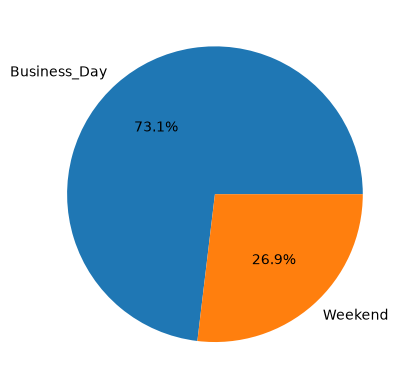

In [73]:
df['Day_Type'].value_counts().plot(kind='pie',autopct='%1.1f%%')

In [74]:
day_type_summary = df.groupby('Day_Type').agg(
    total_accidents = ('Accident Name','count'),
    total_deaths = ('Deaths','sum'),
    total_injuries = ('Injuries','sum')
).assign(total_casualties = lambda x:x['total_deaths'] + x['total_injuries'])

In [75]:
day_type_summary

,total_accidents,total_deaths,total_injuries,total_casualties
Day_Type,,,,
Business_Day,212,5455.0,8194.0,13649.0
Weekend,78,3012.0,3218.0,6230.0


<Axes: xlabel='Day_Type'>

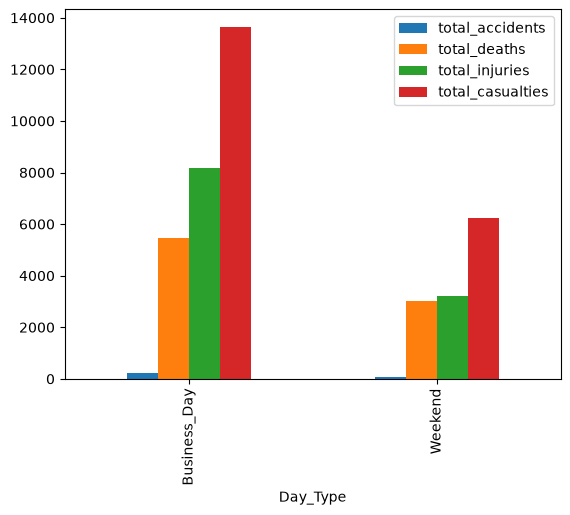

In [76]:
day_type_summary.plot(kind='bar')

In [77]:
working_season = df[df['Season'] != 'Summer']

In [78]:
working_season.groupby('Day_Type').agg(
    total_accidents = ('Accident Name','count'),
    total_deaths = ('Deaths','sum'),
    total_injuries = ('Injuries','sum')
).assign(total_casualties = lambda x: x['total_deaths'] + x['total_injuries']).sort_values('total_casualties',ascending=False)

,total_accidents,total_deaths,total_injuries,total_casualties
Day_Type,,,,
Business_Day,173,4377.0,5353.0,9730.0
Weekend,63,1877.0,2807.0,4684.0


<Axes: xlabel='Day_Type'>

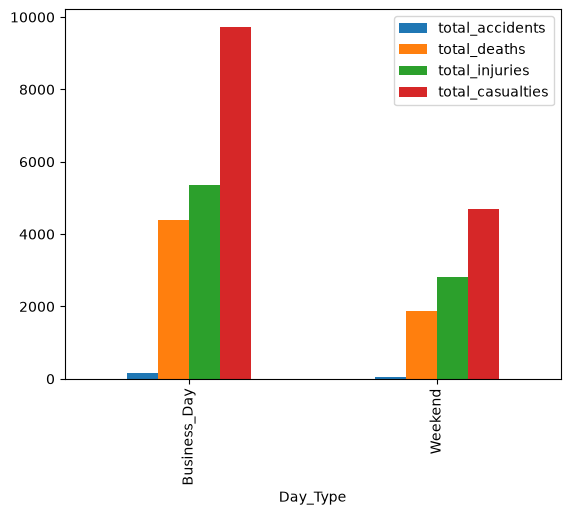

In [79]:
working_season.groupby('Day_Type').agg(
    total_accidents = ('Accident Name','count'),
    total_deaths = ('Deaths','sum'),
    total_injuries = ('Injuries','sum')
).assign(total_casualties = lambda x: x['total_deaths'] + x['total_injuries']).sort_values('total_casualties',ascending=False).plot(kind='bar')

In [80]:
non_summer = df[df.Season != 'Summer']['Day_Type'].value_counts(normalize=True)*100
summer = df[df.Season == 'Summer']['Day_Type'].value_counts(normalize=True)*100
print('Non-Summer Split (%):')
print(non_summer)
print('\nSummer Split (%):')
print(summer)

Non-Summer Split (%):
Day_Type
Business_Day    73.305085
Weekend         26.694915
Name: proportion, dtype: float64

Summer Split (%):
Day_Type
Business_Day    72.222222
Weekend         27.777778
Name: proportion, dtype: float64


<Axes: xlabel='Deaths', ylabel='Count'>

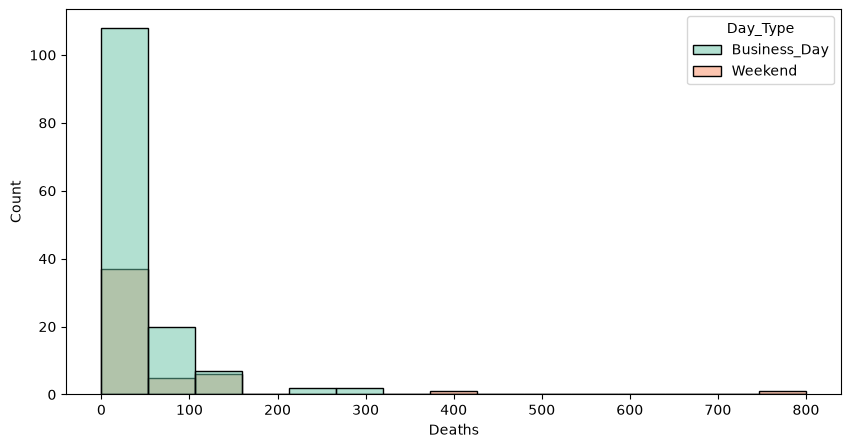

In [81]:
plt.figure(figsize=(10,5))
sns.histplot(
    data=df,
    x='Deaths',
    hue='Day_Type',
    bins=15,
    palette='Set2'
)


# Standard Cause Type
conclusion
- Main Causes -> Weather and technical Faults cause the most accidents (124 and 121), as well as the majority of total deaths and injuries
- Human-Related & Sabotage Factors -> Sabotage recorded 18 accidents with substantial casualties, while Human Error accounted for 26 recorded accidents with lower overall fatality rates
- Money spent -> Most safety funding goes to fixing Technical Fault and Weather problems, because they cause the most casualties

In [82]:
df['Standard Cause Type'].value_counts()

Standard Cause Type
Weather Conditions    124
Technical Fault       121
Human Error            26
Sabotage               18
Unknown                 1
Name: count, dtype: int64

In [83]:
standard_cause_type = df.groupby('Standard Cause Type').agg(
    total_death = ('Deaths','sum'),
    total_injuries = ('Injuries','sum'),
    total_accident = ('Accident Name', 'count')
).sort_values('total_death',ascending=False)
standard_cause_type

,total_death,total_injuries,total_accident
Standard Cause Type,,,
Weather Conditions,3997.0,5104.0,124
Technical Fault,3387.0,4499.0,121
Sabotage,571.0,1601.0,18
Human Error,512.0,208.0,26
Unknown,0.0,0.0,1


In [84]:
df.groupby('Standard Cause Type')['Season'].value_counts().reset_index()

,Standard Cause Type,Season,count
0,Human Error,Monsoon,7
1,Human Error,Summer,6
2,Human Error,Autumn,6
3,Human Error,Winter,5
4,Human Error,Spring,2
5,Sabotage,Winter,6
6,Sabotage,Spring,6
7,Sabotage,Monsoon,4
8,Sabotage,Summer,1
9,Sabotage,Autumn,1


In [85]:
standard_cause = df.groupby(['Year','Standard Cause Type']).agg(
    total_accidents = ('Accident Name', 'count'),
    total_deaths = ('Deaths', 'sum'),
    total_injuries = ('Injuries', 'sum')
).assign(total_casualties = lambda x: x['total_deaths'] + x['total_injuries']).sort_values('total_casualties',ascending=False).reset_index()


In [86]:
fund_allocate_summary = df_fund.groupby('Standard Year').agg(
    safety_grant = ('Railway Safety Fund- Total Grant (cr)','first'),
    safety_expenditure = ('Railway Safety Fund-Actual Expenditure (cr)','first'),
    drf_grant = ('Depreciation Reserve Fund (DRF)','first'),
    drf_expenditure = ('Depreciation Reserve Fund- Actual Utilisation (cr)','first')
).reset_index()


In [87]:
merge_standard = pd.merge(standard_cause, fund_allocate_summary, left_on='Year', right_on='Standard Year', how='left')
merge_standard.reset_index()

,index,Year,Standard Cause Type,total_accidents,total_deaths,total_injuries,total_casualties,Standard Year,safety_grant,safety_expenditure,drf_grant,drf_expenditure
0,0,2023,Technical Fault,3,310.0,1339.0,1649.0,NaN,NaN,NaN,NaN,NaN
1,1,2006,Sabotage,2,237.0,843.0,1080.0,2006.0,4028.52,3045.38,3943.06,3255.59
2,2,1981,Weather Conditions,2,830.0,70.0,900.0,NaN,NaN,NaN,NaN,NaN
3,3,1999,Technical Fault,2,315.0,549.0,864.0,NaN,NaN,NaN,NaN,NaN
4,4,1995,Technical Fault,3,497.0,335.0,832.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
133,133,1974,Human Error,1,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
134,134,2009,Human Error,1,0.0,0.0,0.0,2009.0,2950.00,2890.00,7000.00,7000.00
135,135,2007,Sabotage,1,0.0,0.0,0.0,2007.0,2895.49,2315.54,4545.73,4957.78
136,136,2021,Weather Conditions,1,0.0,0.0,0.0,2021.0,20000.00,18500.00,200.00,200.00


In [88]:
year_totals = merge_standard.groupby('Year')['total_casualties'].transform('sum')
merge_standard['casualty_share'] = merge_standard['total_casualties'] / year_totals
merge_standard['attributed_expenditure'] = merge_standard['casualty_share'] * merge_standard['safety_expenditure']
cause_utilization = merge_standard.groupby('Standard Cause Type')['attributed_expenditure'].sum().sort_values(ascending=False)
cause_utilization.reset_index()

,Standard Cause Type,attributed_expenditure
0,Technical Fault,78069.120758
1,Weather Conditions,69159.660398
2,Human Error,4389.266587
3,Sabotage,3469.942257
4,Unknown,0.000000


# Reforms/Changes
conxlusion

# Merge on Funds_Allocated
Conclusion
- Accidents Are Decreasing -> Total accidents dropped significantly from 2006 to 2021 and 2022
- Fund Usage is High -> The Safety Fund and DRF usage stayed high usually reaching 100% between 2006 to 2022
- Overutilization -> in specific years like 2007,2008,2012, 2016, 2021 safety fund utilization went over 100% (marked as Overutilization)

In [89]:
df_fund[['Ordinary working expense (cr)','Actual ordinary working expense (cr)']] = df_fund[['Ordinary working expense (cr)','Actual ordinary working expense (cr)']].fillna(0)

In [90]:
df_fund.info()

<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 10 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Year                                                17 non-null     str    
 1   Standard Year                                       17 non-null     int64  
 2   Railway Safety Fund- Total Grant (cr)               17 non-null     float64
 3   Railway Safety Fund-Actual Expenditure (cr)         17 non-null     float64
 4   Depreciation Reserve Fund (DRF)                     17 non-null     float64
 5   Depreciation Reserve Fund- Actual Utilisation (cr)  17 non-null     float64
 6   Total Working Expenditure(cr)                       17 non-null     int64  
 7   Total Working Expenditure- Actual expenditure (cr)  17 non-null     float64
 8   Ordinary working expense (cr)                       17 non-null     float64
 9   Actual ordin

In [91]:
df_fund.info()

<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 10 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Year                                                17 non-null     str    
 1   Standard Year                                       17 non-null     int64  
 2   Railway Safety Fund- Total Grant (cr)               17 non-null     float64
 3   Railway Safety Fund-Actual Expenditure (cr)         17 non-null     float64
 4   Depreciation Reserve Fund (DRF)                     17 non-null     float64
 5   Depreciation Reserve Fund- Actual Utilisation (cr)  17 non-null     float64
 6   Total Working Expenditure(cr)                       17 non-null     int64  
 7   Total Working Expenditure- Actual expenditure (cr)  17 non-null     float64
 8   Ordinary working expense (cr)                       17 non-null     float64
 9   Actual ordin

In [92]:
df.columns

Index(['DateTime', 'Year', 'Month', 'Day', 'Accident Name', 'Train Name',
       'Location', 'State', 'Accident Rail Zone', 'Accident Type',
       'Standard Accident Type', 'Cause', 'Deaths', 'Injuries',
       'Rescue Time (hrs)', 'Reforms/Changes', 'Standard Cause Type', 'Season',
       'Day_Type'],
      dtype='str')

In [93]:
accident_summary = df.groupby(df['DateTime'].dt.year).agg(
    total_accident=('Accident Name', 'count'),
    total_death = ('Deaths','sum'),
    total_injuries = ('Injuries','sum')
).reset_index()
accident_summary.rename(columns={'DateTime':'Year'}, inplace=True)

fund_summary = df_fund.groupby('Standard Year').agg(
    safety_grant = ('Railway Safety Fund- Total Grant (cr)','first'),
    safety_expenditure = ('Railway Safety Fund-Actual Expenditure (cr)','first'),
    drf_grant = ('Depreciation Reserve Fund (DRF)','first'),
    drf_expenditure = ('Depreciation Reserve Fund- Actual Utilisation (cr)','first')
).reset_index()
fund_summary.rename(columns={'Standard Year':'Year'}, inplace=True)

merge_df = pd.merge(accident_summary,fund_summary,on='Year',how='outer')

merge_df['safety_utilization_rate'] = (merge_df['safety_expenditure'] / merge_df['safety_grant']) * 100
merge_df['drf_utilization_rate'] = (merge_df['drf_expenditure'] / merge_df['drf_grant'])*100

merge_df.dropna()

,Year,total_accident,total_death,total_injuries,safety_grant,safety_expenditure,drf_grant,drf_expenditure,safety_utilization_rate,drf_utilization_rate
56,2006,3,254.0,843.0,4028.52,3045.38,3943.06,3255.59,75.595504,82.565064
57,2007,2,0.0,32.0,2895.49,2315.54,4545.73,4957.78,79.970575,109.064551
58,2008,1,40.0,0.0,1892.26,1930.10,5803.17,5774.93,101.999725,99.513369
59,2009,3,25.0,0.0,2950.00,2890.00,7000.00,7000.00,97.966102,100.000000
60,2010,14,233.0,289.0,3200.00,3150.00,4500.00,2187.00,98.437500,48.600000
61,2011,10,128.0,723.0,3500.00,3420.00,5700.00,5515.00,97.714286,96.754386
62,2012,11,102.0,170.0,4000.00,3900.00,6160.00,6520.00,97.500000,105.844156
63,2013,6,76.0,55.0,4200.00,4150.00,7000.00,6850.00,98.809524,97.857143
64,2014,6,71.0,189.0,4500.00,4350.00,6500.00,7900.00,96.666667,121.538462
65,2015,7,110.0,468.0,4750.00,4600.00,7775.00,7775.00,96.842105,100.000000


In [94]:
merge_df['drf_utilization_capped'] = merge_df['drf_utilization_rate'].clip(upper=100)
merge_df['safety_utilization_capped'] = merge_df['safety_utilization_rate'].clip(upper=100)

merge_df['drf_status'] = merge_df['drf_utilization_rate'].apply(
    lambda x: 'Overutilization' if x > 100 else 'Normal'
)

merge_df[['Year','drf_utilization_rate','drf_utilization_capped','drf_status']].dropna()

,Year,drf_utilization_rate,drf_utilization_capped,drf_status
56,2006,82.565064,82.565064,Normal
57,2007,109.064551,100.000000,Overutilization
58,2008,99.513369,99.513369,Normal
59,2009,100.000000,100.000000,Normal
60,2010,48.600000,48.600000,Normal
61,2011,96.754386,96.754386,Normal
62,2012,105.844156,100.000000,Overutilization
63,2013,97.857143,97.857143,Normal
64,2014,121.538462,100.000000,Overutilization
65,2015,100.000000,100.000000,Normal


In [95]:
safe_utilization = merge_df.groupby('Year')[['safety_utilization_rate']].sum().assign(safety_status = lambda x : x['safety_utilization_rate'].apply(lambda val : 'Overutilize' if val > 100 else 'Normal')).reset_index()
safe_utilization[safe_utilization['Year'] > 2005]

,Year,safety_utilization_rate,safety_status
56,2006,75.595504,Normal
57,2007,79.970575,Normal
58,2008,101.999725,Overutilize
59,2009,97.966102,Normal
60,2010,98.437500,Normal
61,2011,97.714286,Normal
62,2012,97.500000,Normal
63,2013,98.809524,Normal
64,2014,96.666667,Normal
65,2015,96.842105,Normal


# Merge on Rescue time to generate more insight

In [96]:
df.head(1)

,DateTime,Year,Month,Day,Accident Name,Train Name,Location,State,Accident Rail Zone,Accident Type,Standard Accident Type,Cause,Deaths,Injuries,Rescue Time (hrs),Reforms/Changes,Standard Cause Type,Season,Day_Type
0,1902-09-12,1902,September,12,Bombay-Madras Mail Derailment,Bombay-Madras Mail,"Near Mangapatnam, Kadapa District",Andhra Pradesh,South Central,Derailment,Derailment,Structural failure on bridge,100.0,138.0,4,Enhanced bridge inspections,Weather Conditions,Monsoon,Business_Day


In [97]:
df_rescue.sample(1)

,Rescue ID,Accident Severity,Loacation,Average Rescue Time (hrs)
3,4,Severe,Rural,4.0


In [98]:
df['Rescue Time (hrs)'].head(5)

0    4
1    7
2    7
3    7
4    7
Name: Rescue Time (hrs), dtype: int64

In [99]:
df_rescue['Average Rescue Time (hrs)'].duplicated().sum()

np.int64(1)

# Filling Missing Value

In [100]:
df['Deaths'] = df['Deaths'].fillna(0)
df['Injuries'] = df['Injuries'].fillna(0)

In [102]:
df['Train Name'].value_counts()

Train Name
Unknown                                           20
Passenger Train                                    6
Coromandel Express                                 5
Express Train                                      3
Passenger & Freight Train                          2
                                                  ..
Delhi-Darbhanga Superfast Express                  1
Ernakulam-Hazrat Nizamuddin Millennium Express     1
Kanchanjunga Express                               1
Dibrugarh–Chandigarh Express                       1
Howrah–Mumbai CSMT Mail                            1
Name: count, Length: 231, dtype: int64

In [103]:
df['Train Name'] = df['Train Name'].fillna('Unknown')

In [106]:
df.Cause.value_counts()

Cause
-                                                 52
Unknown                                           39
Signal failure                                     5
Bridge collapse                                    5
Level crossing                                     5
                                                  ..
Tank collapse                                      1
Train collision                                    1
Improper chaining of upper berth                   1
Overspeeding freight train hit passenger train     1
Engine hit a boulder                               1
Name: count, Length: 104, dtype: int64

In [112]:
df['Cause'] = df['Cause'].fillna('Unknown')

In [115]:
df['Reforms/Changes'].value_counts().sum()

np.int64(41)

In [113]:
df.isnull().sum()

DateTime                    0
Year                        0
Month                       0
Day                         0
Accident Name               0
Train Name                  0
Location                    0
State                       0
Accident Rail Zone          0
Accident Type               0
Standard Accident Type      0
Cause                       0
Deaths                      0
Injuries                    0
Rescue Time (hrs)           0
Reforms/Changes           249
Standard Cause Type         0
Season                      0
Day_Type                    0
dtype: int64